<a href="https://colab.research.google.com/github/anamacao/FAPESP-PIBIC-scrapping/blob/main/aaip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from datetime import datetime
import sqlite3

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [22]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
# %%
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

BASE_URL = "https://www.argentina.gob.ar/aaip/noticias"
print("✅ Scraper da AAIP (Argentina) pronto!")

✅ Scraper da AAIP (Argentina) pronto!


In [3]:
DATABASE_NAME = "internet_governance_news.db"

def create_database():
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS articles (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            title TEXT,
            date TEXT,
            author TEXT,
            url TEXT UNIQUE,
            source TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("✅ Banco e tabela 'articles' prontos!")

create_database()


✅ Banco e tabela 'articles' prontos!


In [4]:
def insert_article(title, date, author, url, source):
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    try:
        cursor.execute("""
            INSERT INTO articles (title, date, author, url, source)
            VALUES (?, ?, ?, ?, ?)
        """, (title, date, author, url, source))
        conn.commit()
        return True
    except sqlite3.IntegrityError:
        return False
    finally:
        conn.close()

In [5]:
# %%
def load_articles_from_db():
    conn = sqlite3.connect(DATABASE_NAME)
    df = pd.read_sql("""
        SELECT *
        FROM articles
        ORDER BY date DESC
    """, conn)
    conn.close()
    return df

df_db = load_articles_from_db()
display(df_db.head())
print(f"📦 Total no banco: {len(df_db)} registros")

if len(df_db) == 0:
    print("⚠️  Nenhum registro encontrado no banco de dados. Verifique se o scraping e a inserção estão funcionando corretamente na célula de coleta (`a7b8c9d0`).")

,id,title,date,author,url,source
0,20,La AAIP presenta el nuevo tablero de visualiza...,30 de septiembre de 2025,AAIP,https://www.argentina.gob.ar/noticias/la-aaip-...,AAIP Argentina
1,57,La AAIP y otras autoridades del mundo realizan...,30 de octubre de 2024,AAIP,https://www.argentina.gob.ar/noticias/la-aaip-...,AAIP Argentina
2,29,La AAIP organizó dos actividades virtuales en ...,30 de junio de 2025,AAIP,https://www.argentina.gob.ar/noticias/la-aaip-...,AAIP Argentina
3,10,La AAIP realizó un encuentro con Responsables ...,30 de diciembre de 2025,AAIP,https://www.argentina.gob.ar/noticias/la-aaip-...,AAIP Argentina
4,58,La AAIP presente en el evento 2024 sobre Prote...,29 de octubre de 2024,AAIP,https://www.argentina.gob.ar/noticias/la-aaip-...,AAIP Argentina


📦 Total no banco: 80 registros


In [6]:
# %%
def montar_url(pagina):
    """Monta a URL paginada da AAIP (page=0 é a primeira)."""
    if pagina == 0:
        return BASE_URL
    return f"https://www.argentina.gob.ar/node/37875/noticias?page={pagina}"

def extrair_paragrafos(url):
    """Acessa a página da notícia e extrai os parágrafos principais."""
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        ps = soup.find_all("p")
        textos = [
            p.get_text(strip=True)
            for p in ps
            if len(p.get_text(strip=True).split()) > 10
        ]
        return textos[:5] if textos else ["NA"]
    except:
        return ["NA"]

In [15]:
# %%
noticias = []
TOTAL_PAGES = 36  # margem para cobrir todas as páginas (0-indexed) 36 cobre todas as paginas

for pagina in range(0, TOTAL_PAGES):
    url = montar_url(pagina)
    print(f"📄 Coletando página {pagina + 1}/{TOTAL_PAGES}: {url}")

    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f"⚠️ Erro HTTP {r.status_code} — parando.")
            break
    except Exception as e:
        print(f"⚠️ Erro de conexão: {e}")
        break

    soup = BeautifulSoup(r.text, "html.parser")

    noticia_tags = soup.select("a.panel[href*='/noticias/']")
    if not noticia_tags:
        noticia_tags = soup.select("a[href*='/noticias/']")

    if not noticia_tags:
        print("🏁 Sem mais resultados — fim da coleta.")
        break

    print(f"   {len(noticia_tags)} notícias encontradas")

    for a_tag in noticia_tags:
        h3 = a_tag.find("h3")
        if not h3:
            continue

        titulo = h3.get_text(strip=True)
        link = a_tag.get("href", "")
        if link.startswith("/"):
            link = f"https://www.argentina.gob.ar{link}"

        time_tag = a_tag.find("time")
        data_raw = time_tag.get_text(strip=True) if time_tag else "NA"

        # extrai parágrafos da notícia
        paragrafos = extrair_paragrafos(link)

        # acumula
        noticias.append({
            "titulo": titulo,
            "data": data_raw,
            "link": link,
            "paragrafos": " || ".join(paragrafos),
            "fonte": "AAIP Argentina"
        })

        # grava no banco
        insert_article(
            title=titulo,
            date=data_raw,
            author="AAIP",
            url=link,
            source="AAIP Argentina"
        )

    time.sleep(1)

print(f"\n✅ Total coletado: {len(noticias)} notícias")

df_aaip = pd.DataFrame(noticias)
display(df_aaip.head())

📄 Coletando página 1/36: https://www.argentina.gob.ar/aaip/noticias
   16 notícias encontradas
📄 Coletando página 2/36: https://www.argentina.gob.ar/node/37875/noticias?page=1
   16 notícias encontradas
📄 Coletando página 3/36: https://www.argentina.gob.ar/node/37875/noticias?page=2
   16 notícias encontradas
📄 Coletando página 4/36: https://www.argentina.gob.ar/node/37875/noticias?page=3
   16 notícias encontradas
📄 Coletando página 5/36: https://www.argentina.gob.ar/node/37875/noticias?page=4
   16 notícias encontradas
📄 Coletando página 6/36: https://www.argentina.gob.ar/node/37875/noticias?page=5
   16 notícias encontradas
📄 Coletando página 7/36: https://www.argentina.gob.ar/node/37875/noticias?page=6
   16 notícias encontradas
📄 Coletando página 8/36: https://www.argentina.gob.ar/node/37875/noticias?page=7
   16 notícias encontradas
📄 Coletando página 9/36: https://www.argentina.gob.ar/node/37875/noticias?page=8
   16 notícias encontradas
📄 Coletando página 10/36: https://www.arg

,titulo,data,link,paragrafos,fonte
0,La AAIP participó de la Cumbre Global de la IAPP,29 de abril de 2026,https://www.argentina.gob.ar/noticias/la-aaip-...,El encuentro anual convocó a autoridades y exp...,AAIP Argentina
1,La Red Iberoamericana de Protección de Datos r...,23 de abril de 2026,https://www.argentina.gob.ar/noticias/la-red-i...,La Red recolectará opiniones del mundo académi...,AAIP Argentina
2,La AAIP investiga presuntos incumplimientos a ...,13 de abril de 2026,https://www.argentina.gob.ar/noticias/la-aaip-...,La investigación se inició a partir de denunci...,AAIP Argentina
3,La AAIP encabezó la 65° reunión del Bureau del...,09 de abril de 2026,https://www.argentina.gob.ar/noticias/la-aaip-...,"La reunión convocó a los miembros del Bureau, ...",AAIP Argentina
4,Declaración conjunta de autoridades de protecc...,12 de marzo de 2026,https://www.argentina.gob.ar/noticias/declarac...,La iniciativa plantea principios fundamentales...,AAIP Argentina


In [16]:
def load_articles():
    conn = sqlite3.connect(DATABASE_NAME)
    df = pd.read_sql("""
        SELECT * FROM articles
        ORDER BY date DESC
    """, conn)
    conn.close()
    return df

df_db = load_articles()
print(f"📦 Total no banco: {len(df_db)} registros")
display(df_db.head(20))

📦 Total no banco: 567 registros


,id,title,date,author,url,source
0,125,La AAIP presentó el Plan Estratégico 2023-2025...,31 de octubre de 2023,AAIP,https://www.argentina.gob.ar/noticias/la-aaip-...,AAIP Argentina
1,220,Sexta reunión de la Mesa Nacional de Integrida...,31 de octubre de 2022,AAIP,https://www.argentina.gob.ar/noticias/sexta-re...,AAIP Argentina
2,244,Beatriz Anchorena participó de la 4° Reunión d...,31 de mayo de 2022,AAIP,https://www.argentina.gob.ar/noticias/beatriz-...,AAIP Argentina
3,541,Acceso a la Información en Argentina Abierta,31 de mayo de 2018,AAIP,https://www.argentina.gob.ar/noticias/acceso-l...,AAIP Argentina
4,195,Firma de convenio de colaboración entre la AAI...,31 de marzo de 2023,AAIP,https://www.argentina.gob.ar/noticias/firma-de...,AAIP Argentina
5,295,Protección de datos personales en viajes,31 de marzo de 2021,AAIP,https://www.argentina.gob.ar/noticias/protecci...,AAIP Argentina
6,529,“Hay desafíos que tenemos que resolver y ser c...,31 de julio de 2018,AAIP,https://www.argentina.gob.ar/noticias/hay-desa...,AAIP Argentina
7,396,Turnos online para consultas sobre acceso a la...,31 de enero de 2020,AAIP,https://www.argentina.gob.ar/noticias/turnos-o...,AAIP Argentina
8,397,Turnos online para consultas sobre protección ...,31 de enero de 2020,AAIP,https://www.argentina.gob.ar/noticias/turnos-o...,AAIP Argentina
9,20,La AAIP presenta el nuevo tablero de visualiza...,30 de septiembre de 2025,AAIP,https://www.argentina.gob.ar/noticias/la-aaip-...,AAIP Argentina


In [17]:
keywords = ['digital', 'internet', 'IA', 'tecnología', 'datos', 'privacidad',
            'protección', 'ciberseguridad', 'inteligencia artificial']
pattern = r'|'.join(keywords)

df_filt = df_aaip[
    df_aaip['titulo'].str.contains(pattern, case=False, na=False, regex=True) |
    df_aaip['paragrafos'].str.contains(pattern, case=False, na=False, regex=True)
].copy()

print(f"{len(df_filt)} notícias filtradas (de {len(df_aaip)})")
display(df_filt.head())

567 notícias filtradas (de 567)


,titulo,data,link,paragrafos,fonte
0,La AAIP participó de la Cumbre Global de la IAPP,29 de abril de 2026,https://www.argentina.gob.ar/noticias/la-aaip-...,El encuentro anual convocó a autoridades y exp...,AAIP Argentina
1,La Red Iberoamericana de Protección de Datos r...,23 de abril de 2026,https://www.argentina.gob.ar/noticias/la-red-i...,La Red recolectará opiniones del mundo académi...,AAIP Argentina
2,La AAIP investiga presuntos incumplimientos a ...,13 de abril de 2026,https://www.argentina.gob.ar/noticias/la-aaip-...,La investigación se inició a partir de denunci...,AAIP Argentina
3,La AAIP encabezó la 65° reunión del Bureau del...,09 de abril de 2026,https://www.argentina.gob.ar/noticias/la-aaip-...,"La reunión convocó a los miembros del Bureau, ...",AAIP Argentina
4,Declaración conjunta de autoridades de protecc...,12 de marzo de 2026,https://www.argentina.gob.ar/noticias/declarac...,La iniciativa plantea principios fundamentales...,AAIP Argentina


In [33]:
# %% Análise de Frequência de Palavras-Chave

# Combina títulos e parágrafos em uma única string
text_combined = ' '.join(df_filt['titulo'].fillna('') + ' ' + df_filt['paragrafos'].fillna(''))

# Tokeniza o texto e converte para minúsculas
words = nltk.word_tokenize(text_combined.lower(), language='portuguese')

# Remove stopwords e palavras curtas (opcional, mas recomendado para relevância)
stop_words_pt = set(stopwords.words('portuguese'))
irrelevant_words = {'del', 'los', 'las', 'con', 'una', 'sobre'} # Add the new irrelevant words
filtered_words = [word for word in words if word.isalpha() and word not in stop_words_pt and word not in irrelevant_words and len(word) > 2]

# Conta a frequência das palavras
word_freq = Counter(filtered_words)

# Exibe as 20 palavras mais comuns
print("As 20 palavras mais comuns (títulos e parágrafos):")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

# Cria um DataFrame para visualização
df_word_freq = pd.DataFrame(word_freq.most_common(20), columns=['palavra', 'frequencia'])

# Visualiza a frequência das palavras
fig = px.bar(
    df_word_freq,
    x='frequencia',
    y='palavra',
    orientation='h',
    title='Top 20 Palavras Mais Comuns (Títulos e Parágrafos)',
    labels={'frequencia': 'Frequência', 'palavra': 'Palavra'}
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

As 20 palavras mais comuns (títulos e parágrafos):
datos: 1806
información: 1592
acceso: 1375
protección: 1217
personales: 1094
transparencia: 1045
pública: 964
agencia: 868
aaip: 788
nacional: 672
privacidad: 451
políticas: 438
ley: 428
marco: 359
encuentro: 358
trabajo: 341
consejo: 337
titular: 321
parte: 309
federal: 302


In [25]:
pip install wordcloud

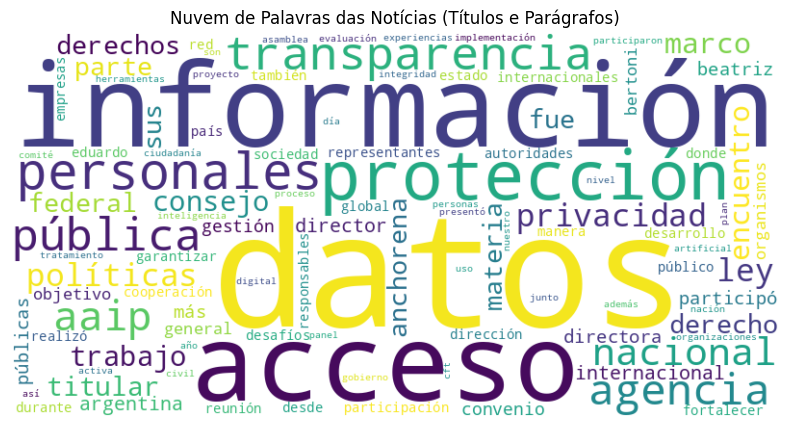

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gera a nuvem de palavras a partir do dicionário de frequências
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    collocations=False # Para evitar que a nuvem priorize bigramas sobre palavras únicas
).generate_from_frequencies(word_freq)

# Exibe a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras das Notícias (Títulos e Parágrafos)')
plt.show()

In [35]:
fig = px.bar(
    df_word_freq,
    x='frequencia',
    y='palavra',
    orientation='h',
    title='Top 20 Temas/Palavras Mais Comuns (Títulos e Parágrafos)',
    labels={'frequencia': 'Frequência', 'palavra': 'Tema/Palavra'}
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [18]:
def plot_charts(df):
    if df.empty:
        print("❌ Sem dados para gráficos")
        return

    # ------------------------------
    # Top 15
    # ------------------------------
    top15 = df.head(15).copy()
    top15['rank'] = range(1, len(top15) + 1)

    fig1 = px.bar(
        top15,
        x='rank',
        y='title',
        orientation='h',
        title='Top 15 Notícias – Internet Governance'
    )
    fig1.update_layout(height=600)
    fig1.show()

    # ------------------------------
    # Pizza por Fonte (BANCO)
    # ------------------------------
    source_count = df["source"].value_counts().reset_index()
    source_count.columns = ["source", "count"]

    fig2 = px.pie(
        source_count,
        names="source",
        values="count",
        title="Distribuição por Fonte"
    )
    fig2.show()

    # ------------------------------
    # Nuvem de Palavras
    # ------------------------------
    text = ' '.join(df['title'].astype(str)).lower()
    words = re.findall(r'\b\w{4,}\b', text)

    wc = (
        pd.Series(words)
        .value_counts()
        .head(20)
        .reset_index()
    )
    wc.columns = ['palavra', 'freq']

    fig3 = px.treemap(
        wc,
        path=['palavra'],
        values='freq',
        title='Nuvem de Palavras – Títulos'
    )
    fig3.show()

In [27]:
import plotly.io as pio
pio.renderers.default = "colab"
plot_charts(df_db)

### Análise da Evolução Temporal das Notícias

In [31]:
import re

# Create a mapping for month names (Spanish to number)
month_mapping = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4, 'maio': 5, 'junho': 6,
    'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12,
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}

def parse_date_with_month_mapping(date_str):
    if pd.isna(date_str) or not isinstance(date_str, str):
        return pd.NaT
    # Replace 'de' with ' ' to simplify format string
    date_str = date_str.replace(' de ', ' ')

    # Replace month names with numbers
    for spanish_month, month_num in month_mapping.items():
        date_str = re.sub(r'\b' + spanish_month + r'\b', str(month_num), date_str, flags=re.IGNORECASE)

    # Now parse the modified string using the simpler format
    return pd.to_datetime(date_str, format='%d %m %Y', errors='coerce')

# Reload df_db to ensure date column is string
df_db = load_articles()

# Apply the custom date parsing function
df_db['date'] = df_db['date'].apply(parse_date_with_month_mapping)

# Remover linhas com datas inválidas (coerced para NaT)
df_db_valid = df_db.dropna(subset=['date']).copy()

# Extrair ano e mês para análise temporal
df_db_valid['year_month'] = df_db_valid['date'].dt.to_period('M')

# Contar artigos por ano/mês
articles_by_month = df_db_valid['year_month'].value_counts().sort_index().reset_index()
articles_by_month.columns = ['year_month', 'count']

# Converter 'year_month' de volta para string para visualização no Plotly
articles_by_month['year_month'] = articles_by_month['year_month'].astype(str)

# Visualizar a evolução temporal
fig = px.line(
    articles_by_month,
    x='year_month',
    y='count',
    title='Número de Notícias Publicadas por Mês',
    labels={'year_month': 'Mês/Ano', 'count': 'Número de Notícias'}
)
fig.update_xaxes(tickangle=45)
fig.update_layout(hovermode="x unified")
fig.show()

In [36]:
# ------------------------------
# Pizza por Fonte (BANCO)
# ------------------------------
source_count = df_db["source"].value_counts().reset_index()
source_count.columns = ["source", "count"]

fig_source_pie = px.pie(
    source_count,
    names="source",
    values="count",
    title="Distribuição por Fonte das Notícias"
)
fig_source_pie.show()

### Evolução Temporal dos Principais Termos/Palavras-Chave

In [37]:
# Merge df_db_valid (for correct date/year_month) with df_aaip (for 'paragrafos')
# Ensure both 'url' and 'link' columns are consistent for merging
df_aaip_temp = df_aaip.rename(columns={'link': 'url', 'titulo': 'title', 'data': 'original_date_str'})
df_combined_for_analysis = pd.merge(df_db_valid, df_aaip_temp[['url', 'paragrafos', 'title']], on='url', how='left', suffixes=('_db', '_aaip'))

# Get top keywords from the previously calculated df_word_freq
top_keywords = df_word_freq['palavra'].head(5).tolist()

# Prepare an empty DataFrame to store temporal keyword counts
keyword_temporal_counts = pd.DataFrame()

# Loop through each top keyword
for keyword in top_keywords:
    # Filter articles containing the keyword (case-insensitive)
    # Using the merged df for title and paragrafos, and year_month
    keyword_articles = df_combined_for_analysis[
        (df_combined_for_analysis['title_aaip'].fillna('').str.contains(keyword, case=False, na=False)) |
        (df_combined_for_analysis['paragrafos'].fillna('').str.contains(keyword, case=False, na=False))
    ].copy()

    # Count occurrences by year_month (unique articles per month that mention the keyword)
    counts = keyword_articles.groupby('year_month').size().reset_index(name='count')
    counts['keyword'] = keyword
    keyword_temporal_counts = pd.concat([keyword_temporal_counts, counts])

# Convert 'year_month' to string for Plotly
keyword_temporal_counts['year_month'] = keyword_temporal_counts['year_month'].astype(str)

# Plotting
fig_keywords_temporal = px.line(
    keyword_temporal_counts,
    x='year_month',
    y='count',
    color='keyword',
    title='Evolução Temporal dos Top 5 Termos/Palavras Chave',
    labels={'year_month': 'Mês/Ano', 'count': 'Número de Notícias'}
)
fig_keywords_temporal.update_xaxes(tickangle=45)
fig_keywords_temporal.update_layout(hovermode="x unified")
fig_keywords_temporal.show()